In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [2]:
df = pd.read_csv('house_sale.csv')

#Initial Exploration on Data

In [3]:
from IPython.display import display

def check_df(df, head=5):
    print("\nSHAPE")
    display(pd.DataFrame(df.shape, index=["Rows", "Columns"], columns=["Count"]))

    print("\nDATA TYPES")
    display(df.dtypes.to_frame(name="Type"))

    print("\nHEAD")
    display(df.head(head))

    print("\nTAIL")
    display(df.tail(head))

    print("\nMISSING VALUES")
    na_df = df.isnull().sum().sort_values(ascending=False).to_frame(name="Missing")
    na_df["Ratio (%)"] = (na_df["Missing"] / len(df) * 100).round(2)
    display(na_df)

    print("\nDESCRIPTIVE STATS")
    display(df.describe().T)

check_df(df)


SHAPE


,Count
Rows,5902
Columns,51



DATA TYPES


,Type
id_x,object
rel_url,object
estate_rel_url_x,object
datetime_scrape_x,object
price,float64
currency_x,object
location,object
attributes,object
city_when,object
city,object



HEAD


...

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
5897,43e59c6b-0a29-4a44-a82f-3c6c17abe6dd,/alqi-satqi?page=139,/items/4674897,2024-10-08 07:32:19.961753+00,67000.000,AZN,Şağan q.,"4 otaqlı, 125 m²","Bakı, dünən 16:14",bakı,07.10.2024,16:14,Təmirli,NaN,NaN,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,f6b58126-06df-4848-8c7e-d9d415627313,43e59c6b-0a29-4a44-a82f-3c6c17abe6dd,/items/4674897,2024-10-08 07:35:53.717949+00,✅Şağan qəs\n✅Olinpiya Kompleksi və 124N Məktəb...,NaN,67000.000,AZN,Kamal,vasitəçi (agent),NaN,NaN,Şağan qəs.,40.492,50.127,yeniləndi: dünən 16:14,143.000,07.10.2024,16:14,f6b58126-06df-4848-8c7e-d9d415627313,NaN,Həyət evi/Bağ evi,NaN,4.000,125 m²,2 sot,var,var,var,f6b58126-06df-4848-8c7e-d9d415627313,/items/4674897,Xəzər r.* Şağan q.
5898,cb5071a2-ab62-4c7b-b947-7ea331d2ace7,/alqi-satqi?page=139,/items/4674895,2024-10-08 07:32:19.961753+00,277700.000,AZN,20 Yanvar m.,"3 otaqlı, 153 m², 5/16 mərtəbə","Bakı, dünən 16:14",bakı,07.10.2024,16:14,NaN,NaN,NaN,Agentlik,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,c60c5a4d-414f-488e-a29b-0d69d5813585,cb5071a2-ab62-4c7b-b947-7ea331d2ace7,/items/4674895,2024-10-08 07:35:53.717949+00,TƏCİLİ SATILIR!!!\nKUPÇALI İPOTEKAYA YARARLIDI...,1 820 AZN/m²,277700.000,AZN,Mədinə xanım,vasitəçi (agent),New House Gənclik,Daşınmaz əmlak agentliyi,Həsən bəy Zərdabi pr.,40.400,49.806,yeniləndi: dünən 16:14,47.000,07.10.2024,16:14,c60c5a4d-414f-488e-a29b-0d69d5813585,NaN,Yeni tikili,5 / 16,3.000,153 m²,NaN,yoxdur,var,var,c60c5a4d-414f-488e-a29b-0d69d5813585,/items/4674895,20 Yanvar m.* Yasamal r.
5899,5bfcf7c6-0765-4e25-b910-94b869231de8,/alqi-satqi?page=139,/items/4406886,2024-10-08 07:32:19.961753+00,150000.000,AZN,Neftçilər m.,"2 otaqlı, 63 m², 11/14 mərtəbə","Bakı, dünən 16:14",bakı,07.10.2024,16:14,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,63d0151d-db29-4d83-9e98-b4891ac3d9b9,5bfcf7c6-0765-4e25-b910-94b869231de8,/items/4406886,2024-10-08 07:35:53.717949+00,************TƏCİLİ SATILIR************\nNEFTÇİ...,2 380 AZN/m²,150000.000,AZN,Real Əmlak,vasitəçi (agent),Real Əmlak Nərimanov,Daşınmaz əmlak agentliyi,Rüstəm Rüstəmov küçəsi,40.413,49.951,yeniləndi: dünən 16:14,461.000,07.10.2024,16:14,63d0151d-db29-4d83-9e98-b4891ac3d9b9,NaN,Yeni tikili,11 / 14,2.000,63 m²,NaN,var,var,NaN,63d0151d-db29-4d83-9e98-b4891ac3d9b9,/items/4406886,Neftçilər m.* Nizami r.
5900,74abe422-8463-4c7f-8580-99e901f491a6,/alqi-satqi?page=139,/items/4621990,2024-10-08 07:32:19.961753+00,310000.000,AZN,8 Noyabr m.,"3 otaqlı, 147 m², 14/16 mərtəbə","Bakı, dünən 16:14",bakı,07.10.2024,16:14,Təmirli,NaN,NaN,Agentlik,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,39aee105-8fc5-4c52-9415-74ad2d57a20d,74abe422-8463-4c7f-8580-99e901f491a6,/items/4621990,2024-10-08 07:35:53.717949+00,*TƏCİLİ SATILIR*\n*KUPÇA ÇIXARIŞ (SƏNƏD)*\n*İP...,2 110 AZN/m²,310000.000,AZN,Süleyman bəy,vasitəçi (agent),New House Nizami,Daşınmaz əmlak agentliyi,Həsən Əliyev küçəsi,40.397,49.825,yeniləndi: dünən 16:14,155.000,07.10.2024,16:14,39aee105-8fc5-4c52-9415-74ad2d57a20d,NaN,Yeni tikili,14 / 16,3.000,147 m²,NaN,var,var,var,39aee105-8fc5-4c52-9415-74ad2d57a20d,/items/4621990,8 Noyabr m.* Nəsimi r.
5901,ecbdb113-cfa6-4d90-be57-3e5b2d89b616,/alqi-satqi?page=139,/items/4674896,2024-10-08 07:32:19.961753+00,265000.000,AZN,Nəriman Nərimanov m.,"3 otaqlı, 101.5 m², 15/17 mərtəbə","Bakı, dünən 16:14",bakı,07.10.2024,16:14,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstati


MISSING VALUES


,Missing,Ratio (%)
Binanın növü,5892,99.830
featured,5651,95.750
vip,5138,87.060
Torpaq sahəsi,4990,84.550
İpoteka,3960,67.100
mortgage,3960,67.100
hour_y,3950,66.930
shop_title,1898,32.160
shop_name,1898,32.160
products_label,1848,31.310



DESCRIPTIVE STATS


,count,mean,std,min,25%,50%,75%,max
price,5902.000,317844.299,577871.766,2500.000,145000.000,216000.000,339000.000,20000000.000
total_price,5901.000,317852.576,577920.555,2500.000,145000.000,216000.000,339000.000,20000000.000
lat,5901.000,40.411,0.063,39.549,40.382,40.397,40.420,41.775
lng,5901.000,49.889,0.135,45.040,49.819,49.857,49.950,50.331
views,5901.000,774.306,2085.936,29.000,119.000,273.000,734.000,110609.000
Otaq sayı,5391.000,3.141,1.326,1.000,2.000,3.000,4.000,19.000


#Data Cleaning


### Find Similar/Duplicate Columns

In [4]:
# Check which column pairs are nearly identical (>95% match)
cols = df.columns.tolist()
similar_pairs = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        try:
            similarity = (df[col1] == df[col2]).mean()
            if similarity > 0.95:
                similar_pairs.append((col1, col2, round(similarity, 4)))
        except Exception:
            pass

similar_pairs


[('id_x', 'estate_id', np.float64(0.9998)),
 ('estate_rel_url_x', 'estate_rel_url_y', np.float64(0.9998)),
 ('estate_rel_url_x', 'estate_rel_url', np.float64(0.9998)),
 ('price', 'total_price', np.float64(0.9997)),
 ('currency_x', 'currency_y', np.float64(0.9998)),
 ('id_y', 'estate_details_id_x', np.float64(0.9998)),
 ('id_y', 'estate_details_id_y', np.float64(0.9998)),
 ('estate_rel_url_y', 'estate_rel_url', np.float64(0.9998)),
 ('estate_details_id_x', 'estate_details_id_y', np.float64(0.9998))]

###Drop Duplicated / ID / URL Columns

In [5]:
df_clean = df.copy()

# Duplicate columns
df_clean = df_clean.drop(columns=[
    'estate_id', 'currency_y', 'estate_rel_url_y', 'estate_rel_url',
    'total_price', 'id_y', 'estate_details_id_y',
    'id_x', 'rel_url', 'estate_rel_url_x', 'estate_details_id_x'
], errors='ignore')

# Useless content columns
df_clean = df_clean.drop(columns=[
    'Binanın növü', 'featured', 'vip', 'Torpaq sahəsi', 'hour_y'
], errors='ignore')

print("Shape after dropping redundant columns:", df_clean.shape)


Shape after dropping redundant columns: (5902, 35)


##Check mortgage vs İpoteka (keep only one)

In [6]:
print("Overlap between mortgage and İpoteka:")
print((df_clean['mortgage'] == df_clean['İpoteka']).mean())
df_clean = df_clean.drop(columns=['mortgage'], errors='ignore')

Overlap between mortgage and İpoteka:
0.0


### Parse Structured String Columns

In [7]:
# Area
df_clean['area'] = df_clean['Sahə'].str.extract(r'(\d+)').astype(float)

# Room count
df_clean['rooms'] = pd.to_numeric(df_clean['Otaq sayı'], errors='coerce')

# Floor / total floors
floor_split = df_clean['Mərtəbə'].str.extract(r'(\d+)\s*/\s*(\d+)')
df_clean['floor']        = pd.to_numeric(floor_split[0], errors='coerce')
df_clean['total_floors'] = pd.to_numeric(floor_split[1], errors='coerce')

df_clean = df_clean.drop(columns=['Sahə', 'Otaq sayı', 'Mərtəbə'])
df_clean[['area', 'rooms', 'floor', 'total_floors']].head()

,area,rooms,floor,total_floors
0,145.000,4.000,7.000,9.000
1,90.000,4.000,NaN,NaN
2,60.000,3.000,NaN,NaN
3,130.000,NaN,NaN,NaN
4,100.000,3.000,15.000,16.000


###Parse Datetime Columns

In [8]:
df_clean['scrape_vaxtı']   = pd.to_datetime(df_clean['datetime_scrape_x'], errors='coerce')
df_clean['scrape_vaxtı_2'] = pd.to_datetime(df_clean['datetime_scrape_y'], errors='coerce')

# Drop raw datetime + day/hour cols (not used in modelling)
df_clean = df_clean.drop(columns=[
    'datetime_scrape_x', 'datetime_scrape_y',
    'day_x', 'hour_x', 'day_y'
], errors='ignore')

# Also drop the parsed datetime objects (not needed for ML)
df_clean = df_clean.drop(columns=['scrape_vaxtı', 'scrape_vaxtı_2'], errors='ignore')


###Clean unit_price (kvadrat_metr_qiyməti)

In [9]:
df_clean['unit_price'] = (
    df_clean['unit_price']
    .astype(str)
    .str.replace('AZN/m²', '', regex=False)
    .str.replace(' ', '', regex=False)
)
df_clean['unit_price'] = pd.to_numeric(df_clean['unit_price'], errors='coerce')


###Rename All Columns to Azerbaijani

In [10]:
df_clean = df_clean.rename(columns={
    'price':          'qiymət',
    'currency_x':     'valyuta',
    'unit_price':     'kvadrat_metr_qiyməti',
    'location':       'yer',
    'address':        'ünvan',
    'city':           'şəhər',
    'city_when':      'şəhər_vaxtı',
    'lat':            'enlik',
    'lng':            'uzunluq',
    'repair':         'təmir_statusu',
    'Təmir':          'təmir_statusu',
    'Kateqoriya':     'kateqoriya',
    'area':           'sahə',
    'rooms':          'otaq_sayı',
    'floor':          'mərtəbə',
    'total_floors':   'ümumi_mərtəbə',
    'İpoteka':        'ipoteka',
    'Çıxarış':        'çıxarış',
    'bill_of_sale':   'alqı_sənədi',
    'views':          'baxış_sayı',
    'img_url':        'şəkil_linki',
    'description':    'təsvir',
    'extra_info':     'əlavə_məlumat',
    'products_label': 'elan_etiketi',
    'owner_name':     'mülkiyyətçi_adı',
    'owner_title':    'mülkiyyətçi_tipi',
    'shop_name':      'agentlik_adı',
    'shop_title':     'agentlik_tipi',
})

# Drop leftover cols not needed
df_clean = df_clean.drop(columns=['şəhər_vaxtı', 'valyuta'], errors='ignore')
print("Columns:", df_clean.columns.tolist())

Columns: ['qiymət', 'yer', 'attributes', 'şəhər', 'təmir_statusu', 'elan_etiketi', 'alqı_sənədi', 'şəkil_linki', 'təsvir', 'kvadrat_metr_qiyməti', 'mülkiyyətçi_adı', 'mülkiyyətçi_tipi', 'agentlik_adı', 'agentlik_tipi', 'ünvan', 'enlik', 'uzunluq', 'updated', 'baxış_sayı', 'kateqoriya', 'təmir_statusu', 'çıxarış', 'ipoteka', 'əlavə_məlumat', 'sahə', 'otaq_sayı', 'mərtəbə', 'ümumi_mərtəbə']


###Fix Duplicate Column (təmir_statusu) and Remove Exact Duplicates

In [11]:
# Standardise values
df_clean['təmir_statusu'] = df_clean['təmir_statusu'].replace({'var': 'Təmirli'})

# Keep only first occurrence of any duplicated column name
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# Remove fully duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows. Shape: {df_clean.shape}")

Removed 0 duplicate rows. Shape: (5902, 27)


###Missing Value Analysis & Imputation

In [12]:
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}
             ).sort_values('missing_%', ascending=False).head(20)


,missing_count,missing_%
ipoteka,3960,67.100
agentlik_adı,1898,32.160
agentlik_tipi,1898,32.160
elan_etiketi,1848,31.310
ümumi_mərtəbə,1412,23.920
kvadrat_metr_qiyməti,1412,23.920
mərtəbə,1412,23.920
alqı_sənədi,1269,21.500
təmir_statusu,1148,19.450
otaq_sayı,511,8.660


In [13]:
cat_cols = df_clean.select_dtypes(include='object').columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
datetime_cols = df_clean.select_dtypes(include='datetime64[ns]').columns


df_clean[cat_cols] = df_clean[cat_cols].fillna('bilinmir')


df_clean[num_cols] = df_clean[num_cols].apply(lambda col: col.fillna(col.median()))


for col in datetime_cols:
    if not df_clean[col].mode().empty:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


print("Remaining NaN:", df_clean.isna().sum().sum())
print("Shape:", df_clean.shape)

Remaining NaN: 0
Shape: (5902, 27)


In [14]:
df_clean.isna().sum()

,0
qiymət,0
yer,0
attributes,0
şəhər,0
təmir_statusu,0
elan_etiketi,0
alqı_sənədi,0
şəkil_linki,0
təsvir,0
kvadrat_metr_qiyməti,0


###Exploratory Data Analysis (EDA)

In [15]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Numeric cols:", num_cols)
print("\nCategorical cols:", cat_cols)

Numeric cols: ['qiymət', 'kvadrat_metr_qiyməti', 'enlik', 'uzunluq', 'baxış_sayı', 'sahə', 'otaq_sayı', 'mərtəbə', 'ümumi_mərtəbə']

Categorical cols: ['yer', 'attributes', 'şəhər', 'təmir_statusu', 'elan_etiketi', 'alqı_sənədi', 'şəkil_linki', 'təsvir', 'mülkiyyətçi_adı', 'mülkiyyətçi_tipi', 'agentlik_adı', 'agentlik_tipi', 'ünvan', 'updated', 'kateqoriya', 'çıxarış', 'ipoteka', 'əlavə_məlumat']


In [16]:
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
qiymət,5902.000,317844.299,577871.766,2500.000,145000.000,216000.000,339000.000,20000000.000
kvadrat_metr_qiyməti,5902.000,2448.070,738.975,407.000,2110.000,2380.000,2660.000,23500.000
enlik,5902.000,40.411,0.063,39.549,40.382,40.397,40.420,41.775
uzunluq,5902.000,49.889,0.135,45.040,49.819,49.857,49.950,50.331
baxış_sayı,5902.000,774.221,2085.770,29.000,119.000,273.000,733.750,110609.000
sahə,5902.000,156.503,1412.095,0.000,67.000,100.000,147.000,100000.000
otaq_sayı,5902.000,3.129,1.268,1.000,2.000,3.000,4.000,19.000
mərtəbə,5902.000,7.819,4.333,1.000,5.000,7.000,10.000,27.000
ümumi_mərtəbə,5902.000,14.252,4.796,1.000,11.000,16.000,17.000,32.000


In [17]:
import matplotlib.pyplot as plt
plt.ion()

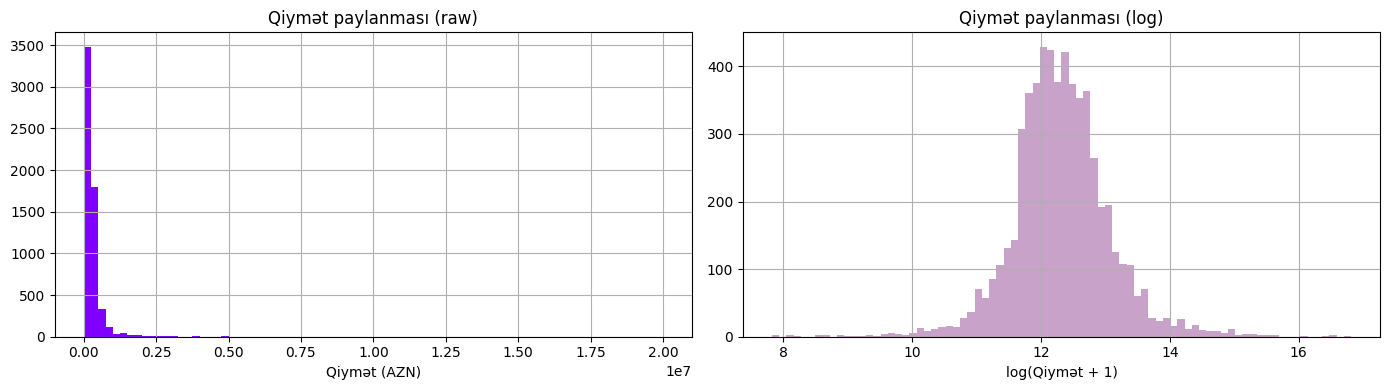

In [18]:
# Target distribution
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean['qiymət'].hist(bins=80, ax=axes[0], color='#7F00FF')
axes[0].set_title('Qiymət paylanması (raw)')
axes[0].set_xlabel('Qiymət (AZN)')

np.log1p(df_clean['qiymət']).hist(bins=80, ax=axes[1], color='#C8A2C8')
axes[1].set_title('Qiymət paylanması (log)')
axes[1].set_xlabel('log(Qiymət + 1)')

plt.tight_layout()
plt.show()

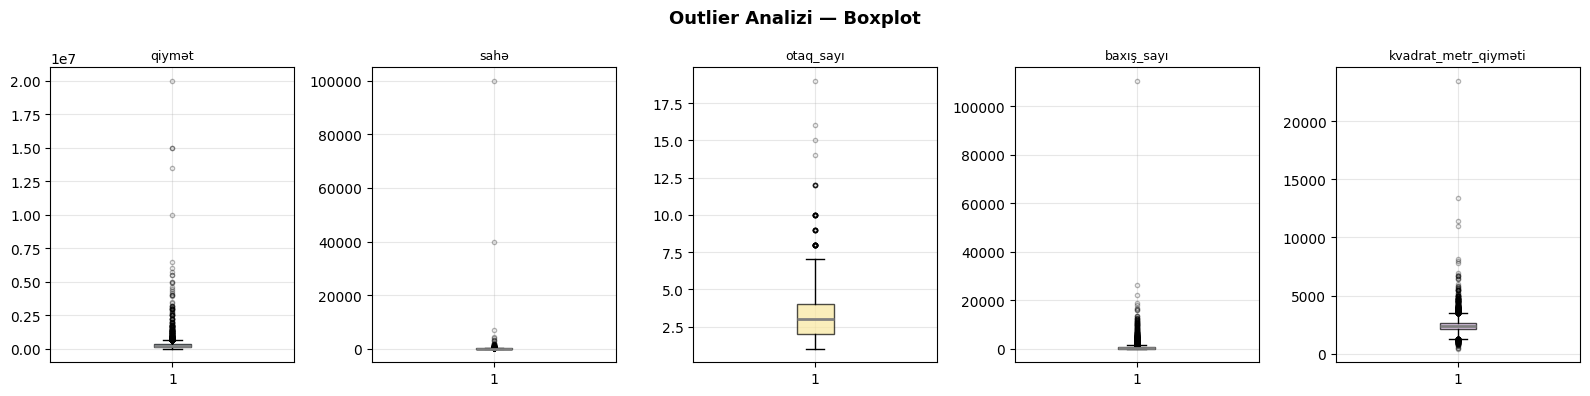

In [19]:
# Boxplot for key numeric columns
plot_cols = ['qiymət', 'sahə', 'otaq_sayı', 'baxış_sayı', 'kvadrat_metr_qiyməti']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(16, 4))
colors = ['#AED6F1', '#A9DFBF', '#F9E79F', '#F5CBA7', '#D2B4DE']

for ax, col, c in zip(axes, plot_cols, colors):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.7),
               medianprops=dict(color='gray', linewidth=2),
               flierprops=dict(marker='.', alpha=0.3))
    ax.set_title(col, fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Outlier Analizi — Boxplot", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


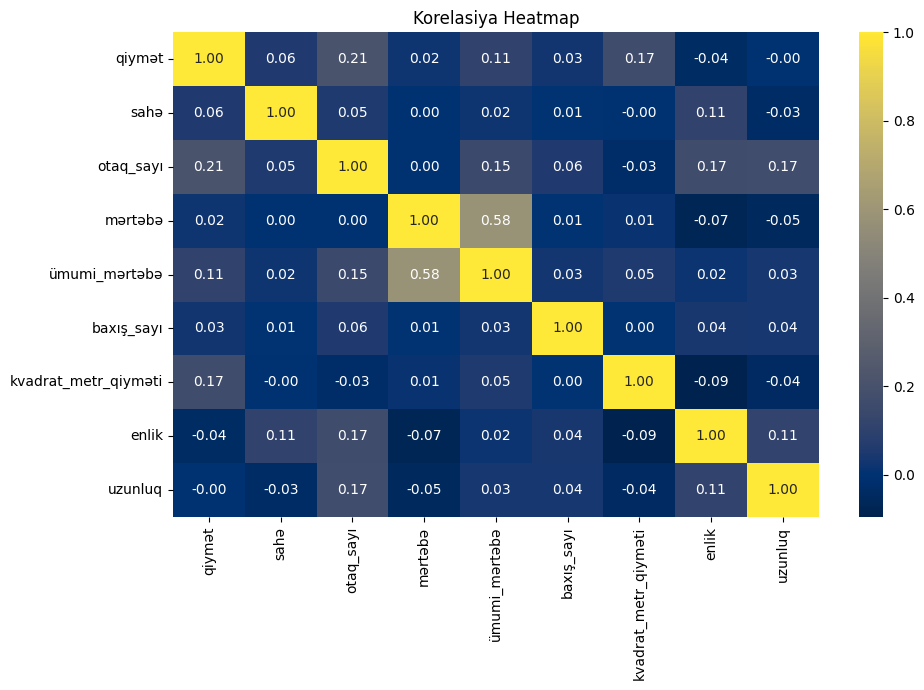

In [20]:
# Correlation heatmap
corr_cols = ['qiymət', 'sahə', 'otaq_sayı', 'mərtəbə', 'ümumi_mərtəbə',
             'baxış_sayı', 'kvadrat_metr_qiyməti', 'enlik', 'uzunluq']
corr_cols = [c for c in corr_cols if c in df_clean.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='cividis', fmt='.2f')
plt.title('Korelasiya Heatmap')
plt.tight_layout()
plt.show()


#Visualization

In [21]:
%matplotlib inline
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

qiymet_bins = [73,85000,95000,105000,115000,125000,135000,145000,155000,
    165000,175000,185000,195000,215000,235000,250000,265000,285000,310000,
    330000,350000,380000,420000,460000,520000,580000,650000,720000,800000,
    900000,1050000,1250000,1500000,1800000,2200000,2800000,3500000,4200000,4600000]
hist_cnt = [12,180,420,870,1450,2380,3200,4900,5800,6400,6100,5900,5300,
    7200,5800,4900,4200,3800,3500,2900,4200,2800,2100,1600,1200,800,520,
    320,210,140,90,55,32,18,10,5,3,2,1]

kat_labels = ["Yeni tikili","Köhnə tikili","Həyət evi/Bağ evi"]
kat_cnt    = [57874, 18096, 15540]

otaq_labels = ["1 otaq","2 otaq","3 otaq","4 otaq","5 otaq","6+ otaq"]
otaq_med    = [118000,165000,225000,310000,420000,580000]

mert_labels = list(range(1,21))
mert_med    = [155000,168000,185000,198000,210000,215000,220000,235000,
    245000,258000,270000,265000,258000,250000,240000,232000,225000,218000,212000,205000]

yer_labels = ["Nəriman Nərimanov m.","Elmlər Akademiyası m.","Nizami m.",
    "28 May m.","Gənclik m.","İnşaatçılar m.","Şah İsmayıl Xətai m.",
    "Nəsimi r.","Nərimanov r.","Həzi Aslanov m."]
yer_med = [310000,295000,340000,285000,275000,230000,260000,290000,245000,195000]

status_labels = ["Təmir var","Təmir yox","Çıxarış var","Çıxarış yox","İpoteka var","İpoteka yox"]
status_vals   = [79044,12466,71291,20219,31177,60333]
status_colors = ["#639922","#E24B4A","#185FA5","#E24B4A","#BA7517","#E24B4A"]

np.random.seed(42)
seed_areas  = [40,50,55,60,65,70,75,80,85,90,95,100,110,120,130,140,150,160,180,200]
base_prices = [85,110,120,135,145,155,165,175,185,195,205,215,235,260,285,315,345,375,430,490]
scatter_x, scatter_y = [], []
for _ in range(600):
    idx = np.random.randint(0, len(seed_areas))
    a = seed_areas[idx] + (np.random.rand()-0.5)*seed_areas[idx]*0.3
    p = base_prices[idx]*1000 + (np.random.rand()-0.5)*base_prices[idx]*800
    scatter_x.append(round(a))
    scatter_y.append(round(p/1000)*1000)
scatter_x = np.array(scatter_x)
scatter_y = np.array(scatter_y)

def fmt(n):
    if n>=1e6: return f"{n/1e6:.1f}M"
    if n>=1e3: return f"{n/1e3:.0f}K"
    return str(n)

from IPython.display import display

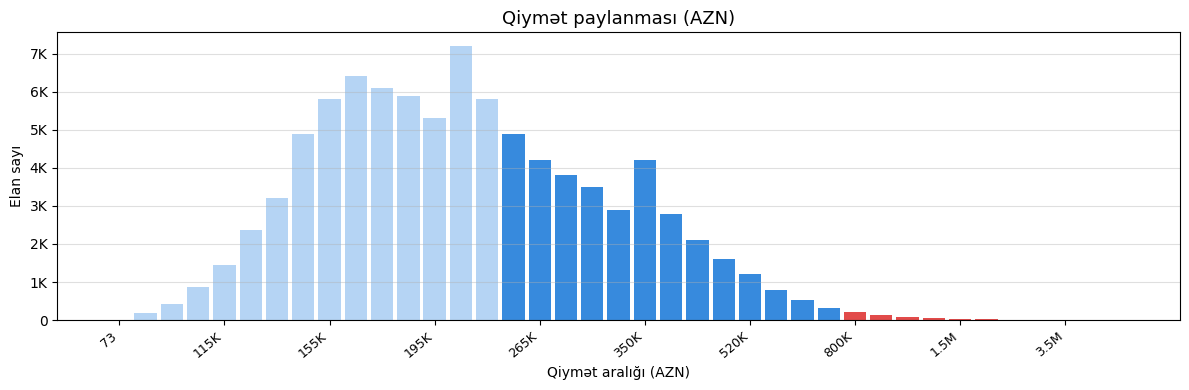

In [22]:
fig, ax = plt.subplots(figsize=(12,4))
colors = ["#B5D4F4" if i<15 else "#378ADD" if i<28 else "#E24B4A" for i in range(len(hist_cnt))]
ax.bar(range(len(hist_cnt)), hist_cnt, color=colors, width=0.85, linewidth=0)
ax.set_title("Qiymət paylanması (AZN)", fontsize=13)
ax.set_xticks(range(0,len(qiymet_bins),4))
ax.set_xticklabels([fmt(qiymet_bins[i]) for i in range(0,len(qiymet_bins),4)], rotation=40, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: fmt(int(v))))
ax.set_xlabel("Qiymət aralığı (AZN)")
ax.set_ylabel("Elan sayı")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
display(fig)
plt.close()

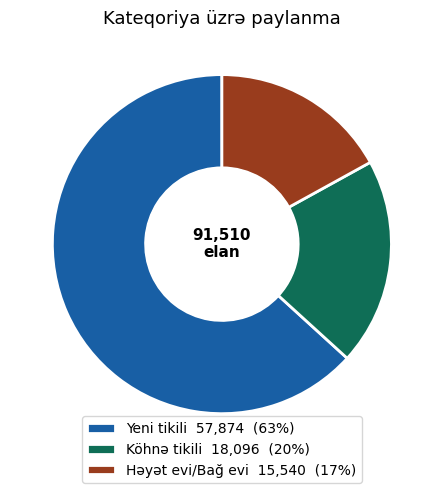

In [23]:
fig, ax = plt.subplots(figsize=(6,5))
kat_colors = ["#185FA5","#0F6E56","#993C1D"]
total = sum(kat_cnt)
wedges, _ = ax.pie(kat_cnt, colors=kat_colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
legend_labels = [f"{l}  {c:,}  ({round(c/total*100)}%)" for l,c in zip(kat_labels,kat_cnt)]
ax.legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5,-0.08), fontsize=10)
centre = plt.Circle((0,0), 0.45, color="white")
ax.add_artist(centre)
ax.text(0, 0, f"{total:,}\nelan", ha="center", va="center", fontsize=11, fontweight="bold")
ax.set_title("Kateqoriya üzrə paylanma", fontsize=13)
plt.tight_layout()
display(fig)
plt.close()

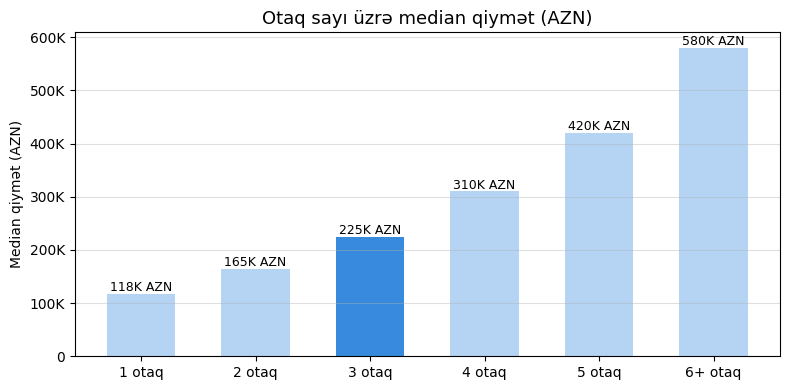

In [24]:
fig, ax = plt.subplots(figsize=(8,4))
bar_colors = ["#B5D4F4" if i!=2 else "#378ADD" for i in range(len(otaq_labels))]
bars = ax.bar(otaq_labels, otaq_med, color=bar_colors, width=0.6, linewidth=0)
for bar, val in zip(bars, otaq_med):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
        fmt(val)+" AZN", ha="center", fontsize=9)
ax.set_title("Otaq sayı üzrə median qiymət (AZN)", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: fmt(int(v))))
ax.set_ylabel("Median qiymət (AZN)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
display(fig)
plt.close()


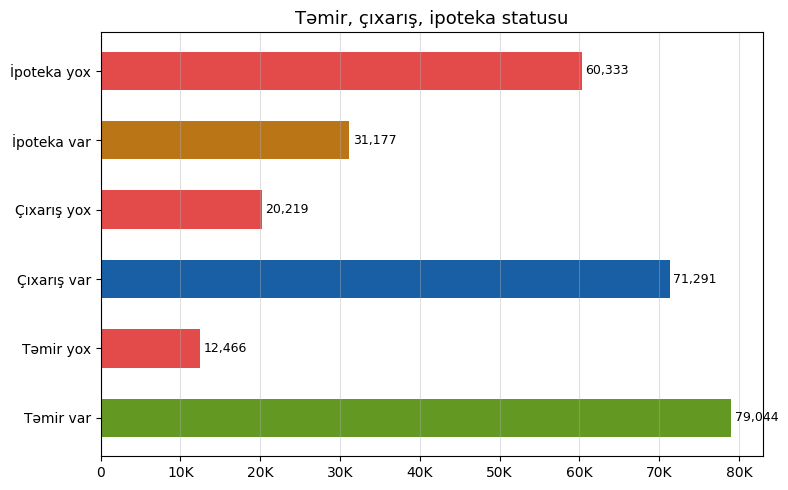

In [25]:
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.barh(status_labels, status_vals, color=status_colors, height=0.55, linewidth=0)
for bar, val in zip(bars, status_vals):
    ax.text(bar.get_width()+400, bar.get_y()+bar.get_height()/2,
        f"{val:,}", va="center", fontsize=9)
ax.set_title("Təmir, çıxarış, ipoteka statusu", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: fmt(int(v))))
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
display(fig)
plt.close()

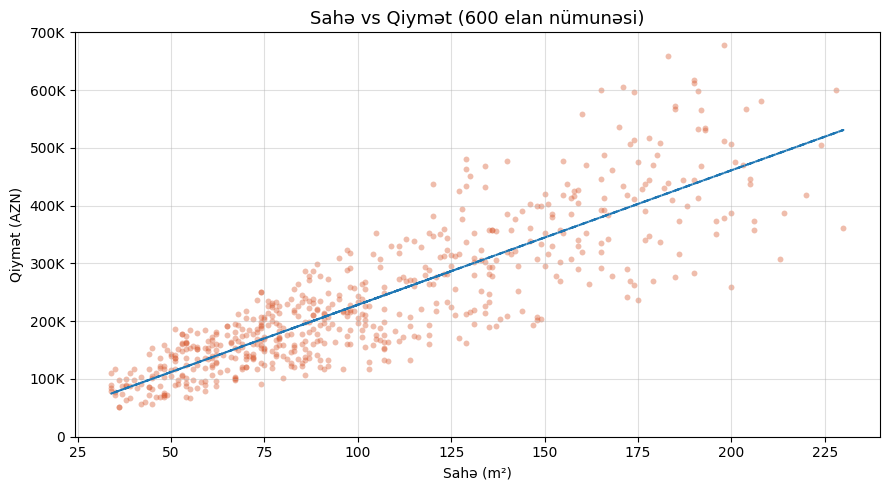

In [27]:
# ======================
# SCATTER (Sahə vs Qiymət)
# ======================
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter
ax.scatter(
    scatter_x,
    scatter_y,
    color="#D85A30",
    alpha=0.4,
    s=18,
    linewidths=0
)

# Trend line (çox vacib!)
z = np.polyfit(scatter_x, scatter_y, 1)
p = np.poly1d(z)
ax.plot(
    scatter_x,
    p(scatter_x),
    linestyle="--"
)

# Title və labels
ax.set_title("Sahə vs Qiymət (600 elan nümunəsi)", fontsize=13)
ax.set_xlabel("Sahə (m²)")
ax.set_ylabel("Qiymət (AZN)")

# Format
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: fmt(int(v)))
)

# Limit
ax.set_ylim(0, 700000)

# Grid
ax.grid(alpha=0.4)

# Layout
plt.tight_layout()
display(fig)
plt.close()


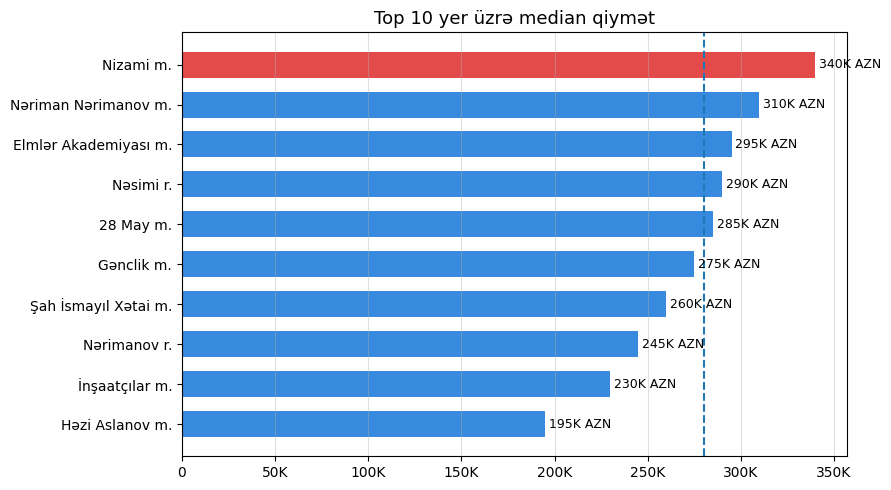

In [28]:

# HORIZONTAL BAR (Yer üzrə median qiymət)
fig, ax = plt.subplots(figsize=(9, 5))

# Sort
sorted_idx = np.argsort(yer_med)
s_labels = [yer_labels[i] for i in sorted_idx]
s_vals   = [yer_med[i] for i in sorted_idx]

# Highlight (ən bahalı yer)
max_idx = np.argmax(s_vals)

colors = [
    "#E24B4A" if i == max_idx else "#378ADD"
    for i in range(len(s_vals))
]

# Bar chart
bars = ax.barh(
    s_labels,
    s_vals,
    color=colors,
    height=0.65,
    linewidth=0
)

# Value label-lar
def add_labels(bars, values, offset=2000):
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{fmt(val)} AZN",
            va="center",
            fontsize=9
        )

add_labels(bars, s_vals)

# Median line (çox vacib insight üçün)
median_val = np.median(s_vals)
ax.axvline(median_val, linestyle="--")

# Title
ax.set_title("Top 10 yer üzrə median qiymət", fontsize=13)

# Format
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: fmt(int(v)))
)

# Grid
ax.grid(axis="x", alpha=0.4)

# Layout
plt.tight_layout()
display(fig)
plt.close()

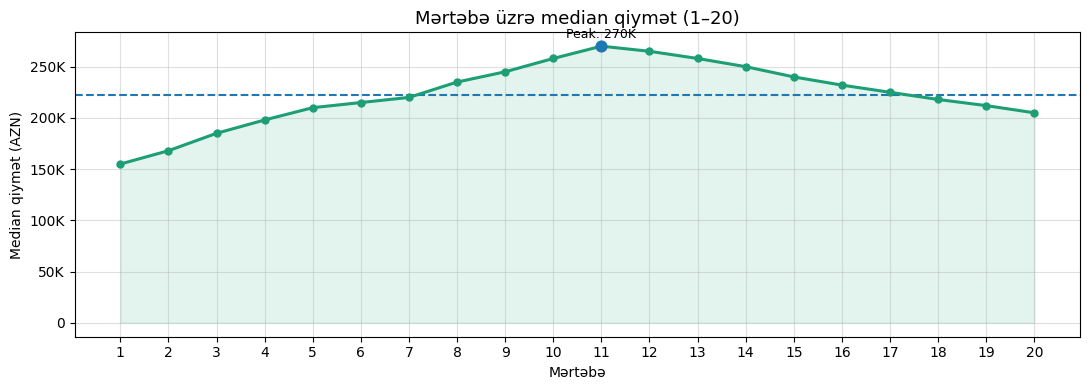

In [29]:
# ======================
# LINE CHART (Mərtəbə üzrə median qiymət)
# ======================
fig, ax = plt.subplots(figsize=(11, 4))

# Line plot
ax.plot(
    mert_labels,
    mert_med,
    color="#1D9E75",
    linewidth=2.2,
    marker="o",
    markersize=5,
    markerfacecolor="#1D9E75",
    zorder=3
)

# Fill area
ax.fill_between(
    mert_labels,
    mert_med,
    alpha=0.12,
    color="#1D9E75"
)

# Median xətt (insight üçün)
median_val = np.median(mert_med)
ax.axhline(median_val, linestyle="--")

# Peak (ən yüksək nöqtə)
max_idx = np.argmax(mert_med)
ax.scatter(
    mert_labels[max_idx],
    mert_med[max_idx],
    s=60,
    zorder=4
)

# Label peak point
ax.text(
    mert_labels[max_idx],
    mert_med[max_idx] + 8000,
    f"Peak: {fmt(mert_med[max_idx])}",
    ha="center",
    fontsize=9
)

# Titles
ax.set_title("Mərtəbə üzrə median qiymət (1–20)", fontsize=13)
ax.set_xlabel("Mərtəbə")
ax.set_ylabel("Median qiymət (AZN)")

# Axis format
ax.set_xticks(mert_labels)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: fmt(int(v)))
)

# Grid
ax.grid(alpha=0.4)

# Layout
plt.tight_layout()
display(fig)
plt.close()

In [30]:
!pip install plotly pandas numpy -q

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
print('Kitabxanalar yükləndi')

Kitabxanalar yükləndi


In [31]:
import pandas as pd

# =========================
# 1. Extract district from ünvan
# =========================
districts = ['Sabunçu','Xətai','Yasamal','Binəqədi','Nəsimi','Nizami','Səbail','Suraxanı','Pirəkəşkül']

def extract_district(text):
    if pd.isna(text):
        return 'bilinmir'
    for d in districts:
        if d.lower() in str(text).lower():
            return d
    return 'digər'

df_clean['ünvan'] = df_clean['ünvan'].apply(extract_district)

# =========================
# 2. Group + plot (YOUR SAME CODE)
# =========================
df_city = df_clean.groupby(['ünvan','kateqoriya'])['qiymət'].median().reset_index()

df_city.columns = ['ünvan','kateqoriya','orta_qiymət']

df_city = df_city.sort_values('orta_qiymət', ascending=True)

fig3 = px.bar(
    df_city,
    x='orta_qiymət',
    y='ünvan',
    color='kateqoriya',
    orientation='h',
    # 🔥 REMOVE this for cleaner plot (important)
    # animation_frame='kateqoriya',
    title='Şəhər üzrə mediana qiymət (kateqoriyaya görə)',
    labels={'orta_qiymət':'Mediana qiymət (AZN)', 'ünvan':'Şəhər'},
    template='plotly_white'
)

fig3.update_layout(height=600)
fig3.show()

In [32]:
df_clean.columns

Index(['qiymət', 'yer', 'attributes', 'şəhər', 'təmir_statusu', 'elan_etiketi', 'alqı_sənədi', 'şəkil_linki', 'təsvir', 'kvadrat_metr_qiyməti', 'mülkiyyətçi_adı', 'mülkiyyətçi_tipi', 'agentlik_adı', 'agentlik_tipi', 'ünvan', 'enlik', 'uzunluq', 'updated', 'baxış_sayı', 'kateqoriya', 'çıxarış', 'ipoteka', 'əlavə_məlumat', 'sahə', 'otaq_sayı', 'mərtəbə', 'ümumi_mərtəbə'], dtype='object')

In [33]:
# qiymət_qrupu sütununu yarat
df_clean['qiymət_qrupu'] = pd.cut(
    df_clean['qiymət'],
    bins=[0, 50000, 100000, 200000, 500000, float('inf')],
    labels=['0-50K', '50K-100K', '100K-200K', '200K-500K', '500K+']
)

# Sonra chart kodu
erazi_qrup = (
    df_clean.groupby(['ünvan', 'qiymət_qrupu'], observed=True)
      .agg(ümumi_baxış=('baxış_sayı', 'sum'),
           elan_sayı=('qiymət', 'count'),
           orta_qiymət=('qiymət', 'mean'))
      .reset_index()
      .sort_values('ümumi_baxış', ascending=False)
)
erazi_qrup['orta_qiymət'] = erazi_qrup['orta_qiymət'].round(0)

fig1 = px.bar(
    erazi_qrup,
    x='ünvan',
    y='ümumi_baxış',
    color='qiymət_qrupu',
    animation_frame='qiymət_qrupu',
    hover_data={'elan_sayı': True, 'orta_qiymət': ':,.0f'},
    title='📍 Əraziyə və Qiymət Qrupuna görə Ümumi Baxış Sayı',
    labels={'ünvan': 'Ərazi', 'ümumi_baxış': 'Baxış sayı',
            'qiymət_qrupu': 'Qiymət qrupu'},
    color_discrete_sequence=px.colors.sequential.Viridis,
    template='plotly_white',
    height=500,
)
fig1.update_layout(
    xaxis_tickangle=-35,
    legend_title_text='Qiymət qrupu',
    font=dict(family='Arial', size=13),
    title_font_size=16,
    updatemenus=[dict(type='buttons', showactive=False,
                      buttons=[dict(label='▶ Oynat',
                                   method='animate',
                                   args=[None, dict(frame=dict(duration=900, redraw=True),
                                                    fromcurrent=True)])])],
)
fig1.show()

In [34]:
# Remove outliers and invalid prices
q_low = df_clean['qiymət'].quantile(0.01)
q_high = df_clean['qiymət'].quantile(0.99)

df_plot = df_clean[
    (df_clean['qiymət'] > 0) &                    # remove negatives/zeros
    (df_clean['qiymət'] >= q_low) &               # remove bottom 1% outliers
    (df_clean['qiymət'] <= q_high) &              # remove top 1% outliers
    (df_clean['otaq_sayı'].between(1, 10))         # focus on realistic room counts
].dropna(subset=['otaq_sayı', 'qiymət'])

fig2 = px.box(
    df_plot,
    x='otaq_sayı', y='qiymət',
    color='kateqoriya',
    points='suspectedoutliers',
    title='Otaq sayına görə qiymət paylanması',
    labels={'otaq_sayı': 'Otaq sayı', 'qiymət': 'Qiymət (AZN)'},
    template='plotly_white'
)
fig2.update_layout(height=450)
fig2.show()

In [35]:
"""
XƏRİTƏ 1 — Hər evə ən yaxın metro stansiyası

"""

# ── KİTABXANALAR ─────────────────────────────────────────────────────────────
!pip install folium -q

import folium
import math
import random
from IPython.display import display, HTML

random.seed(42)

# ── BAKI METRO STANSİYALARI (real koordinatlar) ──────────────────────────────
metro_stansiyalari = [
    {"ad": "İçərişəhər",           "lat": 40.3664, "lon": 49.8364},
    {"ad": "Sahil",                 "lat": 40.3697, "lon": 49.8402},
    {"ad": "28 May",                "lat": 40.3791, "lon": 49.8492},
    {"ad": "Gənclik",               "lat": 40.3867, "lon": 49.8522},
    {"ad": "Nəriman Nərimanov",     "lat": 40.4052, "lon": 49.8671},
    {"ad": "Bakmil",                "lat": 40.4241, "lon": 49.8793},
    {"ad": "Ulduz",                 "lat": 40.4094, "lon": 49.8538},
    {"ad": "Koroğlu",               "lat": 40.4028, "lon": 49.8469},
    {"ad": "Qara Qarayev",          "lat": 40.4089, "lon": 49.9012},
    {"ad": "Neftçilər",             "lat": 40.4023, "lon": 49.9231},
    {"ad": "Xalqlar Dostluğu",      "lat": 40.3989, "lon": 49.9456},
    {"ad": "Əhmədli",               "lat": 40.3945, "lon": 49.9612},
    {"ad": "Həzi Aslanov",          "lat": 40.3890, "lon": 49.9734},
    {"ad": "8 Noyabr",              "lat": 40.3731, "lon": 49.8312},
    {"ad": "Elmlər Akademiyası",    "lat": 40.3736, "lon": 49.8431},
    {"ad": "İnşaatçılar",           "lat": 40.3794, "lon": 49.8270},
    {"ad": "20 Yanvar",             "lat": 40.3862, "lon": 49.8208},
    {"ad": "Memar Əcəmi",           "lat": 40.3965, "lon": 49.8105},
    {"ad": "Nəsimi",                "lat": 40.4073, "lon": 49.8022},
    {"ad": "Azadlıq Prospekti",     "lat": 40.4167, "lon": 49.7912},
    {"ad": "Dərnəgül",              "lat": 40.4261, "lon": 49.7813},
    {"ad": "Cəfər Cabbarlı",        "lat": 40.3774, "lon": 49.8481},
    {"ad": "Nizami",                "lat": 40.3726, "lon": 49.8481},
]

# ── NÜMUNƏ EVLƏR (Bakı koordinat aralığında) ─────────────────────────────────
def random_baki_ev(n=80):
    evler = []
    lat_min, lat_max = 40.355, 40.430
    lon_min, lon_max = 49.790, 49.980
    qiymetler = [85000,120000,150000,180000,220000,260000,310000,380000,450000,550000]
    otaq_lar  = [1, 2, 3, 4, 5]
    for i in range(n):
        evler.append({
            "id":     i + 1,
            "lat":    round(random.uniform(lat_min, lat_max), 5),
            "lon":    round(random.uniform(lon_min, lon_max), 5),
            "qiymet": random.choice(qiymetler),
            "otaq":   random.choice(otaq_lar),
            "sahə":   random.randint(45, 180),
        })
    return evler

evler = random_baki_ev(80)

# ── MƏSAFƏ HESABLAMA (Haversine) ─────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # metr
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def en_yaxin_metro(ev):
    min_m = float("inf")
    yaxin = None
    for m in metro_stansiyalari:
        d = haversine(ev["lat"], ev["lon"], m["lat"], m["lon"])
        if d < min_m:
            min_m = d
            yaxin = m
    return yaxin, round(min_m)

# ── XƏRİTƏ QURULMASI ─────────────────────────────────────────────────────────
m = folium.Map(
    location=[40.395, 49.882],
    zoom_start=12,
    tiles="CartoDB positron"
)

# Metro stansiyaları — mavi ulduz işarəsi
for stan in metro_stansiyalari:
    folium.Marker(
        location=[stan["lat"], stan["lon"]],
        popup=folium.Popup(f"<b>🚇 {stan['ad']}</b>", max_width=200),
        tooltip=f"Metro: {stan['ad']}",
        icon=folium.Icon(color="blue", icon="train", prefix="fa")
    ).add_to(m)

# Ev markerlər + ən yaxın metroya xətt
for ev in evler:
    yaxin_m, mesafe = en_yaxin_metro(ev)

    # Ev markeri
    popup_html = f"""
    <div style='font-family:Arial;font-size:13px;min-width:180px'>
        <b>🏠 Ev #{ev['id']}</b><br>
        💰 {ev['qiymet']:,} AZN<br>
        🛏 {ev['otaq']} otaq &nbsp;|&nbsp; 📐 {ev['sahə']} m²<br>
        <hr style='margin:6px 0'>
        <b>🚇 Ən yaxın metro:</b><br>
        {yaxin_m['ad']}<br>
        📍 Məsafə: <b>{mesafe} m</b>
    </div>
    """
    folium.CircleMarker(
        location=[ev["lat"], ev["lon"]],
        radius=7,
        color="#E05A2B",
        fill=True,
        fill_color="#E05A2B",
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=240),
        tooltip=f"Ev #{ev['id']} — {ev['qiymet']:,} AZN | Metro: {yaxin_m['ad']} ({mesafe}m)"
    ).add_to(m)

    # Evdən metroya xətt
    folium.PolyLine(
        locations=[[ev["lat"], ev["lon"]], [yaxin_m["lat"], yaxin_m["lon"]]],
        color="#185FA5",
        weight=1.2,
        opacity=0.4,
        dash_array="6 4"
    ).add_to(m)

# Legenda
legend_html = """
<div style="
    position: fixed; bottom: 30px; left: 30px; z-index: 1000;
    background: white; padding: 14px 18px; border-radius: 10px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.2); font-family: Arial; font-size: 13px;">
    <b>📌 Legenda</b><br><br>
    <span style="color:#E05A2B;">●</span> Ev elanı<br>
    <span style="color:#185FA5;">🚇</span> Metro stansiyası<br>
    <span style="color:#185FA5; opacity:0.5;">- -</span> Ən yaxın metro xətti
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Xəritəni göstər
display(m)


In [36]:
!pip install folium -q

import folium
import math
import pandas as pd
from IPython.display import display

# Koordinatlar
df_clean = df_clean.dropna(subset=['enlik', 'uzunluq'])
df_clean['enlik']   = pd.to_numeric(df_clean['enlik'],   errors='coerce')
df_clean['uzunluq'] = pd.to_numeric(df_clean['uzunluq'], errors='coerce')

# sirket_adı sütunu yarat
df_clean['sirket_adı'] = df_clean['agentlik_adı'].fillna(df_clean['mülkiyyətçi_adı']).fillna('Fərdi satıcı')

# Bakı həddlərini filter et
df_clean = df_clean[
    (df_clean['enlik'].between(40.30, 40.50)) &
    (df_clean['uzunluq'].between(49.70, 50.10))
]

# Nümunə üçün 100 elan
df_sample = df_clean.sample(min(100, len(df_clean)), random_state=42).reset_index(drop=True)
print(f"✅ {len(df_sample)} elan xəritəyə əlavə ediləcək")

# ── MƏSAFƏ
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    a = math.sin(math.radians(lat2-lat1)/2)**2 + \
        math.cos(phi1)*math.cos(phi2)*math.sin(math.radians(lon2-lon1)/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def en_yaxin(ev_lat, ev_lon, obyektler):
    min_d, yaxin = float("inf"), None
    for obj in obyektler:
        d = haversine(ev_lat, ev_lon, obj["lat"], obj["lon"])
        if d < min_d:
            min_d, yaxin = d, obj
    return yaxin, round(min_d)

# ── İNFRASTRUKTUR OBYEKTLƏRİ
marketler = [
    {"ad": "Bravo (Nəriman Nərimanov)",   "lat": 40.4035, "lon": 49.8670},
    {"ad": "Bravo (28 May)",              "lat": 40.3800, "lon": 49.8510},
    {"ad": "Araz (Elmlər Akademiyası)",   "lat": 40.3740, "lon": 49.8440},
    {"ad": "Makro (Həzi Aslanov)",        "lat": 40.3880, "lon": 49.9720},
    {"ad": "Bravo (Nizami küç.)",         "lat": 40.3730, "lon": 49.8350},
    {"ad": "Araz (İnşaatçılar)",          "lat": 40.3800, "lon": 49.8260},
    {"ad": "Supermarket (Koroğlu)",       "lat": 40.4020, "lon": 49.8460},
    {"ad": "Bravo (Nəsimi)",              "lat": 40.4070, "lon": 49.8030},
]

aptekler = [
    {"ad": "Aptek (28 May)",              "lat": 40.3795, "lon": 49.8500},
    {"ad": "Aptek (Gənclik)",             "lat": 40.3870, "lon": 49.8530},
    {"ad": "Aptek (Nizami küç.)",         "lat": 40.3720, "lon": 49.8360},
    {"ad": "Aptek (Qara Qarayev)",        "lat": 40.4085, "lon": 49.9010},
    {"ad": "Aptek (Memar Əcəmi)",         "lat": 40.3960, "lon": 49.8110},
    {"ad": "Aptek (Nəriman Nərimanov)",   "lat": 40.4050, "lon": 49.8680},
]

mekteblar = [
    {"ad": "Məktəb №6 (Nəriman Nərimanov)",  "lat": 40.4060, "lon": 49.8690},
    {"ad": "Məktəb №18 (Sahil)",             "lat": 40.3710, "lon": 49.8420},
    {"ad": "Məktəb №23 (Gənclik)",           "lat": 40.3880, "lon": 49.8540},
    {"ad": "Məktəb №45 (Nizami)",            "lat": 40.3735, "lon": 49.8370},
    {"ad": "Məktəb №132 (Həzi Aslanov)",     "lat": 40.3900, "lon": 49.9740},
    {"ad": "Məktəb №7 (Nəsimi)",             "lat": 40.4080, "lon": 49.8040},
]

universitetler = [
    {"ad": "BDU",              "lat": 40.3812, "lon": 49.8356},
    {"ad": "ADNSU",            "lat": 40.3892, "lon": 49.8317},
    {"ad": "AzTU",             "lat": 40.3946, "lon": 49.8612},
    {"ad": "UNEC",             "lat": 40.3876, "lon": 49.8493},
    {"ad": "ADA Universiteti", "lat": 40.3756, "lon": 49.8283},
    {"ad": "ADU",              "lat": 40.3987, "lon": 49.8654},
]

avtobus_dayanacaqlari = [
    {"ad": "Nəriman Nərimanov m.", "lat": 40.4048, "lon": 49.8662,
     "marsrutlar": ["1", "6", "24", "65", "88", "125", "176"]},
    {"ad": "28 May m.",            "lat": 40.3785, "lon": 49.8495,
     "marsrutlar": ["2", "5", "10", "46", "120", "H1"]},
    {"ad": "Gənclik m.",           "lat": 40.3865, "lon": 49.8518,
     "marsrutlar": ["3", "14", "41", "76", "125", "189"]},
    {"ad": "Nizami küç.",          "lat": 40.3728, "lon": 49.8345,
     "marsrutlar": ["5", "8", "88", "116", "142"]},
    {"ad": "Sahil m.",             "lat": 40.3695, "lon": 49.8398,
     "marsrutlar": ["2", "7", "15", "62", "109"]},
    {"ad": "Həzi Aslanov m.",      "lat": 40.3887, "lon": 49.9725,
     "marsrutlar": ["13", "50", "93", "157", "184"]},
    {"ad": "Qara Qarayev m.",      "lat": 40.4082, "lon": 49.9005,
     "marsrutlar": ["24", "33", "60", "163", "197"]},
    {"ad": "Xalqlar Dostluğu m.", "lat": 40.3982, "lon": 49.9448,
     "marsrutlar": ["13", "33", "93", "157"]},
    {"ad": "Memar Əcəmi m.",       "lat": 40.3968, "lon": 49.8108,
     "marsrutlar": ["20", "55", "96", "173", "204"]},
    {"ad": "Nəsimi r.",            "lat": 40.4075, "lon": 49.8028,
     "marsrutlar": ["20", "44", "55", "96", "173"]},
    {"ad": "Koroğlu m.",           "lat": 40.4022, "lon": 49.8467,
     "marsrutlar": ["1", "24", "60", "163", "184", "198"]},
    {"ad": "İnşaatçılar m.",       "lat": 40.3802, "lon": 49.8272,
     "marsrutlar": ["19", "41", "76", "116", "189"]},
    {"ad": "Azadlıq pr.",          "lat": 40.4160, "lon": 49.7920,
     "marsrutlar": ["19", "44", "96", "173", "204"]},
    {"ad": "Bakmil m.",            "lat": 40.4238, "lon": 49.8788,
     "marsrutlar": ["6", "65", "88", "176"]},
    {"ad": "Elmlər Akademiyası m.","lat": 40.3740, "lon": 49.8440,
     "marsrutlar": ["5", "7", "15", "62", "109", "142"]},
]

# ── XƏRİTƏ
m = folium.Map(location=[40.390, 49.882], zoom_start=12, tiles="CartoDB positron")

# LAYER-LƏR
layer_evler   = folium.FeatureGroup(name="🏠 Evlər",                 show=True)
layer_market  = folium.FeatureGroup(name="🛒 Marketlər",             show=True)
layer_aptek   = folium.FeatureGroup(name="💊 Apteklər",              show=True)
layer_mekteb  = folium.FeatureGroup(name="🏫 Məktəblər",             show=True)
layer_univer  = folium.FeatureGroup(name="🎓 Universitetlər",        show=True)
layer_avtobus = folium.FeatureGroup(name="🚌 Avtobus dayanacaqları", show=True)

# ── İNFRASTRUKTUR MARKERLƏRİ
for obj in marketler:
    folium.Marker([obj["lat"], obj["lon"]],
        tooltip=obj["ad"],
        popup=folium.Popup(f"<b>🛒 {obj['ad']}</b>", max_width=200),
        icon=folium.Icon(color="green", icon="shopping-cart", prefix="fa")
    ).add_to(layer_market)

for obj in aptekler:
    folium.Marker([obj["lat"], obj["lon"]],
        tooltip=obj["ad"],
        popup=folium.Popup(f"<b>💊 {obj['ad']}</b>", max_width=200),
        icon=folium.Icon(color="red", icon="plus-square", prefix="fa")
    ).add_to(layer_aptek)

for obj in mekteblar:
    folium.Marker([obj["lat"], obj["lon"]],
        tooltip=obj["ad"],
        popup=folium.Popup(f"<b>🏫 {obj['ad']}</b>", max_width=200),
        icon=folium.Icon(color="orange", icon="book", prefix="fa")
    ).add_to(layer_mekteb)

for obj in universitetler:
    folium.Marker([obj["lat"], obj["lon"]],
        tooltip=obj["ad"],
        popup=folium.Popup(f"<b>🎓 {obj['ad']}</b>", max_width=200),
        icon=folium.Icon(color="purple", icon="graduation-cap", prefix="fa")
    ).add_to(layer_univer)

for obj in avtobus_dayanacaqlari:
    marsrut_str = " · ".join(obj["marsrutlar"])
    popup_html = f"""
    <div style='font-family:Arial;font-size:12px;min-width:180px'>
        <b>🚌 {obj['ad']}</b><br>
        <hr style='margin:5px 0'>
        <b>Marşrutlar:</b><br>
        <span style='font-size:13px;color:#00008B;font-weight:bold'>{marsrut_str}</span>
    </div>
    """
    folium.Marker([obj["lat"], obj["lon"]],
        tooltip=f"🚌 {obj['ad']} | Marşrutlar: {marsrut_str}",
        popup=folium.Popup(popup_html, max_width=250),
        icon=folium.Icon(color="darkblue", icon="bus", prefix="fa")
    ).add_to(layer_avtobus)

# ── EV MARKERLƏRİ
for _, ev in df_sample.iterrows():
    lat, lon = ev['enlik'], ev['uzunluq']

    ym, md   = en_yaxin(lat, lon, marketler)
    ya, ad   = en_yaxin(lat, lon, aptekler)
    yme, me  = en_yaxin(lat, lon, mekteblar)
    yu, ud   = en_yaxin(lat, lon, universitetler)
    yav, avd = en_yaxin(lat, lon, avtobus_dayanacaqlari)

    marsrut_str = " · ".join(yav["marsrutlar"])
    sirket  = ev.get('sirket_adı',  'Fərdi satıcı')
    qiymet  = ev.get('qiymət',      0)
    otaq    = ev.get('otaq_sayı',   '-')
    kat     = ev.get('kateqoriya',  '-')
    unvan   = ev.get('ünvan',       '-')

    popup_html = f"""
    <div style='font-family:Arial;font-size:12px;min-width:230px;line-height:1.8'>
        <b style='font-size:14px'>🏠 Ev elanı</b><br>
        💰 <b>{qiymet:,.0f} AZN</b><br>
        🛏 {otaq} otaq &nbsp;|&nbsp; 🏗 {kat}<br>
        📍 {unvan}<br>
        🏢 <b>Şirkət:</b> {sirket}
        <hr style='margin:6px 0;border-color:#ddd'>
        🛒 <b>Market:</b> {ym['ad'].split('(')[0]} — <b>{md} m</b><br>
        💊 <b>Aptek:</b> {ya['ad'].split('(')[0]} — <b>{ad} m</b><br>
        🏫 <b>Məktəb:</b> {yme['ad'].split('(')[0]} — <b>{me} m</b><br>
        🎓 <b>Universitet:</b> {yu['ad']} — <b>{ud} m</b><br>
        🚌 <b>Dayanacaq:</b> {yav['ad']} — <b>{avd} m</b><br>
        <span style='color:#00008B;font-weight:bold'>🚍 {marsrut_str}</span>
    </div>
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        color="#E05A2B", fill=True, fill_color="#E05A2B", fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"🏠 {qiymet:,.0f} AZN | 🏢 {sirket}"
    ).add_to(layer_evler)

# Layerları əlavə et
for layer in [layer_market, layer_aptek, layer_mekteb,
              layer_univer, layer_avtobus, layer_evler]:
    layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Legenda
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
    background:white;padding:14px 18px;border-radius:10px;
    box-shadow:0 2px 12px rgba(0,0,0,0.18);font-family:Arial;font-size:12px;line-height:2">
    <b>📌 Legenda</b><br>
    <span style='color:#E05A2B'>●</span> Ev (üstünə klik et)<br>
    🛒 Market &nbsp; 💊 Aptek<br>
    🏫 Məktəb &nbsp; 🎓 Universitet<br>
    🚌 Avtobus dayanacağı<br>
    <hr style='margin:5px 0;border-color:#eee'>
    <i style='font-size:10px;color:#888'>Evə klik etdikdə şirkət adı<br>
    və avtobus marşrutları görünür</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

display(m)

✅ 100 elan xəritəyə əlavə ediləcək


##Outlier Removal

In [37]:
def outlier_thresholds(df, col, q1=0.25, q3=0.75):
    # Q1 - 25% kvantili (aşağı sərhəd)
    Q1 = df[col].quantile(q1)

    # Q3 - 75% kvantili (yuxarı sərhəd)
    Q3 = df[col].quantile(q3)

    # IQR - interkvartil aralıq (Q3 - Q1)
    IQR = Q3 - Q1

    # Aşağı və yuxarı outlier sərhədlərinin hesablanması
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR


# Outlier-ləri silmədən əvvəl sayını hesablamaq (report etmək üçün)
for col in ['qiymət', 'sahə', 'baxış_sayı', 'kvadrat_metr_qiyməti']:

    # Həmin sütun üçün aşağı və yuxarı sərhədlər
    low, up = outlier_thresholds(df_clean, col)

    # Outlier olan sətirlərin sayı
    n = ((df_clean[col] < low) | (df_clean[col] > up)).sum()

    # Nəticəni çap edirik
    print(f"{col}: {n} outlier (aşağı sərhəd={low:.0f}, yuxarı sərhəd={up:.0f})")

qiymət: 369 outlier  (up=-132500, low=607500)
sahə: 287 outlier  (up=-36, low=240)
baxış_sayı: 545 outlier  (up=-709, low=1478)
kvadrat_metr_qiyməti: 249 outlier  (up=1015, low=3775)


In [38]:
# Qiymət üçün IQR metodu ilə outlier-ləri silirik
low_q, up_q = outlier_thresholds(df_clean, 'qiymət')

# Qiyməti aşağı və yuxarı sərhədlər daxilində olan sətirləri saxlayırıq
df_clean = df_clean[(df_clean['qiymət'] >= low_q) & (df_clean['qiymət'] <= up_q)]

# baxış_sayı üçün 99%-lik kvantili (yuxarı limit) hesablayırıq
q99_baxis = df_clean['baxış_sayı'].quantile(0.99)

# 99%-dən böyük olan (çox yüksək) baxış saylarını silirik
df_clean = df_clean[df_clean['baxış_sayı'] <= q99_baxis]

# Təmizləmədən sonra datasetin ölçüsünü göstəririk
print("Shape after outlier removal:", df_clean.shape)


df_clean['qiymət'].describe()

Shape after outlier removal: (4721, 29)


,qiymət
count,4721.000
mean,228608.605
std,117047.083
min,3500.000
25%,142000.000
50%,200000.000
75%,295000.000
max,600000.000


##Feature Engineering

In [39]:
# 1 kvadrat metr üçün qiyməti hesablayırıq
df_clean['qiymət_per_m2'] = df_clean['qiymət'] / df_clean['sahə'].replace(0, np.nan)

# (floor ratio)
df_clean['mərtəbə_nisbəti'] = df_clean['mərtəbə'] / df_clean['ümumi_mərtəbə'].replace(0, np.nan)

df_clean['zemin_mərtəbə'] = (df_clean['mərtəbə'] == 1).astype(int)

df_clean['son_mərtəbə'] = (df_clean['mərtəbə'] == df_clean['ümumi_mərtəbə']).astype(int)

# Yeni feature-lər əlavə edildikdən sonra datasetin ölçüsünü göstəririk
print("New features added. Shape:", df_clean.shape)

New features added. Shape: (4721, 33)


#Modelling Preparation

###Define df_model — drop non-feature columns

In [40]:
drop_cols = ['şəkil_linki', 'təsvir', 'əlavə_məlumat', 'mülkiyyətçi_adı', 'ünvan']
df_model = df_clean.drop(columns=drop_cols, errors='ignore').copy()

print("df_model shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

df_model shape: (4721, 28)
Columns: ['qiymət', 'yer', 'attributes', 'şəhər', 'təmir_statusu', 'elan_etiketi', 'alqı_sənədi', 'kvadrat_metr_qiyməti', 'mülkiyyətçi_tipi', 'agentlik_adı', 'agentlik_tipi', 'enlik', 'uzunluq', 'updated', 'baxış_sayı', 'kateqoriya', 'çıxarış', 'ipoteka', 'sahə', 'otaq_sayı', 'mərtəbə', 'ümumi_mərtəbə', 'qiymət_qrupu', 'sirket_adı', 'qiymət_per_m2', 'mərtəbə_nisbəti', 'zemin_mərtəbə', 'son_mərtəbə']


###Encoding

In [41]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for low-cardinality categoricals
le = LabelEncoder()
le_cols = ['təmir_statusu', 'elan_etiketi', 'alqı_sənədi',
           'mülkiyyətçi_tipi', 'agentlik_tipi', 'kateqoriya',
           'çıxarış', 'ipoteka']
for col in le_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Target Encoding for high-cardinality categoricals
for col in ['yer', 'agentlik_adı']:
    if col in df_model.columns:
        means = df_model.groupby(col)['qiymət'].mean()
        df_model[col] = df_model[col].map(means).astype(float)

# One-Hot Encoding for şəhər
if 'şəhər' in df_model.columns:
    df_model = pd.get_dummies(df_model, columns=['şəhər'], drop_first=True)

print("After encoding — object cols remaining:")
print(df_model.select_dtypes(include='object').columns.tolist())
print("Shape:", df_model.shape)

After encoding — object cols remaining:
['attributes', 'updated', 'sirket_adı']
Shape: (4721, 28)


##Train-Test Split

In [42]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [43]:
df_model_no_leak = df_model.copy()

df_model_no_leak = df_model_no_leak.drop(columns=[
    "kvadrat_metr_qiyməti",
    "qiymət_per_m2",
    "qiymət_qrupu",
    "attributes",
    "updated",
    "sirket_adı"
], errors="ignore")

In [44]:
target = "qiymət"

X = df_model_no_leak.drop(columns=[target])
y = df_model_no_leak[target]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [46]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns

In [49]:
bool_cols = X_train.select_dtypes(include="bool").columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [51]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=12
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    print("Training:", name)

    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

Training: Linear Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: XGBoost


In [75]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values("R2", ascending=False)

results_df

,Model,MAE,RMSE,R2
4,XGBoost,31666.187,49870.627,0.818
2,Random Forest,33272.346,52114.847,0.801
3,Gradient Boosting,35651.999,55120.688,0.778
1,Decision Tree,41267.346,65839.416,0.683
0,Linear Regression,50056.139,206923.524,-2.135


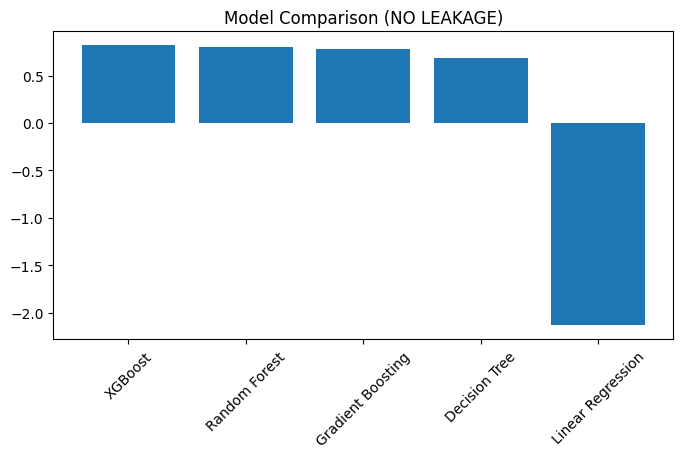

In [76]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison (NO LEAKAGE)")
plt.xticks(rotation=45)
plt.show()

In [77]:
best_model_name = results_df.iloc[0]["Model"]
print(best_model_name)

XGBoost


In [78]:
best_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

best_model.fit(X_train_transformed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test_transformed)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 30568.8324229084
RMSE: 49147.533133850826
R2: 0.8231356098920766


In [80]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_transformed,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std:", cv_scores.std())

CV Mean R2: 0.8213534558930379
CV Std: 0.01270006355166346


In [81]:
y_train_log = np.log1p(y_train)

best_model.fit(X_train_transformed, y_train_log)

y_pred = np.expm1(best_model.predict(X_test_transformed))

In [84]:
importances = best_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
13,num__sahə,0.211
10,num__kateqoriya,0.136
0,num__yer,0.134
14,num__otaq_sayı,0.113
11,num__çıxarış,0.065
7,num__enlik,0.043
3,num__alqı_sənədi,0.040
8,num__uzunluq,0.037
1,num__təmir_statusu,0.028
19,num__son_mərtəbə,0.025


In [85]:
from sklearn.metrics import r2_score

# predictions
y_train_pred = model.predict(X_train_transformed)
y_test_pred = model.predict(X_test_transformed)

# scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.9771054880225416
Test R²: 0.8178930096998986
